In [24]:
#Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#Models ML
from sklearn.svm import SVC
#Metrics
from sklearn.metrics import confusion_matrix,accuracy_score
# from sklearn.metrics import mean_squared_error,r2_score
# from sklearn.metrics import roc_curve, auc

In [25]:
data = pd.read_csv('Heart attack.csv')
data.head()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative


In [26]:
data.shape

(1319, 9)

In [27]:
# There is not NaN or null values in columns
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            1319 non-null   int64  
 1   gender         1319 non-null   int64  
 2   impluse        1319 non-null   int64  
 3   pressurehight  1319 non-null   int64  
 4   pressurelow    1319 non-null   int64  
 5   glucose        1319 non-null   float64
 6   kcm            1319 non-null   float64
 7   troponin       1319 non-null   float64
 8   class          1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [28]:
data = pd.get_dummies(data, columns = ['class'], drop_first = True, dtype=int)
data

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class_positive
0,64,1,66,160,83,160.0,1.80,0.012,0
1,21,1,94,98,46,296.0,6.75,1.060,1
2,55,1,64,160,77,270.0,1.99,0.003,0
3,64,1,70,120,55,270.0,13.87,0.122,1
4,55,1,64,112,65,300.0,1.08,0.003,0
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,0
1315,66,1,84,125,55,149.0,1.33,0.172,1
1316,45,1,85,168,104,96.0,1.24,4.250,1
1317,54,1,58,117,68,443.0,5.80,0.359,1


In [29]:
data.describe()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class_positive
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942,0.614102
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568,0.486991
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000,0.000000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000,0.000000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000,1.000000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500,1.000000
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000,1.000000


In [30]:
print(len(data[data['class_positive'] == 1]))
print(len(data[data['class_positive'] == 0]))

810
509


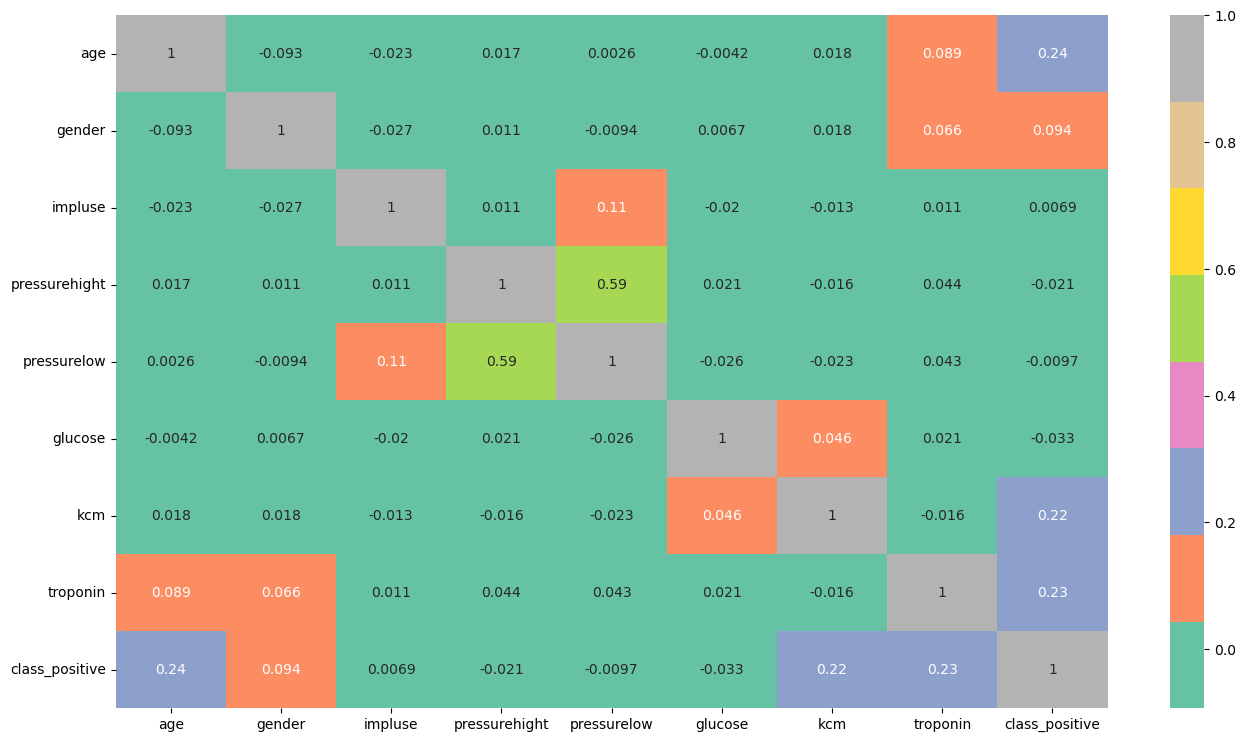

In [33]:
plt.figure(figsize =(16,9))
corr = data.corr()
sns.heatmap(corr, annot = True, cmap = 'Set2') # use capital 'Set' instead of 'set' 
plt.show()

In [34]:
data = data.drop(['impluse', 'pressurelow'], axis = 1)

In [35]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1:]

In [36]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 0)

In [38]:
svc = SVC()
svc.fit(x_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [39]:
y_pred = svc.predict(x_test)

svc_accuracy = round(accuracy_score(y_test, y_pred), 5)*100
svc_accuracy

60.985

In [40]:
d = x_test.iloc[0:1]
d

,age,gender,pressurehight,glucose,kcm,troponin
658,53,1,116,98.0,6.04,0.003


In [41]:
y_test.iloc[0:1]
y_test

,class_positive
658,0
406,1
1202,1
202,0
1187,0
...,...
608,0
194,1
240,1
1154,0


All test dataset rows =  264


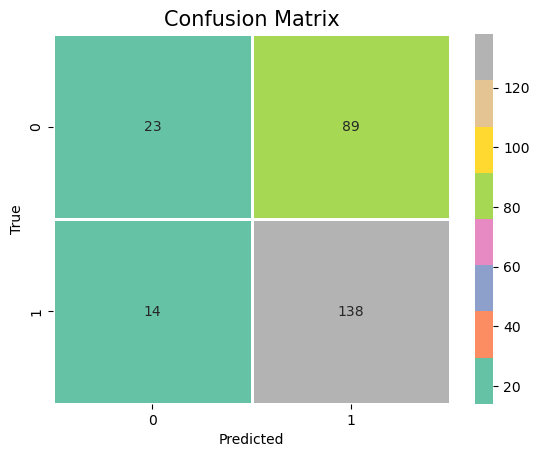

In [43]:
print("All test dataset rows = ", len(x_test))
cm = confusion_matrix(y_test, y_pred)
class_label = [0,1]
df_cm = pd.DataFrame(cm, index =class_label, columns = class_label)
sns.heatmap(df_cm, annot = True, cmap = 'Set2', linewidths = 2, fmt = 'd')
plt.title('Confusion Matrix', fontsize=15)
plt.xlabel("Predicted")
plt.ylabel('True')
plt.show()